In [78]:
# Environment setup

import numpy as np
import matplotlib.pyplot as plt
from fontTools.misc.psCharStrings import read_smallInt1


# Rotation tranform

## Rotating  a 2-d vector


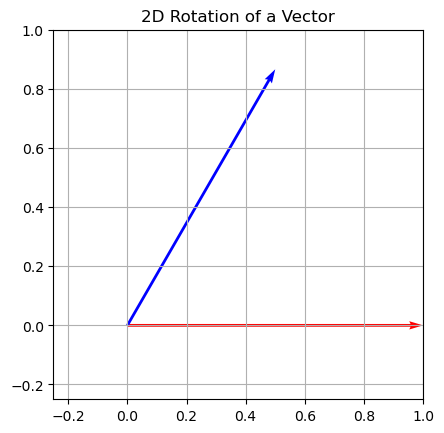

In [79]:
theta = np.pi / 3 # define angle of rotation here

c, s = np.cos(theta), np.sin(theta)

vector = np.array([1,0])
rotation_transform = np.array([[c ,-s],
                               [s,  c]])
vector_rotated = rotation_transform @ vector

plt.figure(1)
plt.quiver(0, 0, vector[0], vector[1], angles='xy', scale_units='xy', scale=1, color="red")
plt.quiver(0,0, vector_rotated[0], vector_rotated[1], angles='xy', scale_units='xy', scale=1, color="blue")
plt.xlim(-.25, 1)
plt.ylim(-.25, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("2D Rotation of a Vector")
plt.grid(True)
plt.show()


# QR using Given's rotations transforms

## Given's rotations

In [80]:
def givens_rotation(a,b):
    """
    Compute c, s such that
    [c  s] [a] = [r]
    [-s c] [b]   [0]
    """
    if b == 0:
        return 1,0, 0.0, abs(a)
    r = np.hypot(a,b) # calculates hypotenuse
    c = a / r
    s = b / r
    return c, s, r

## demostrating given's rotation's effect on a vector.

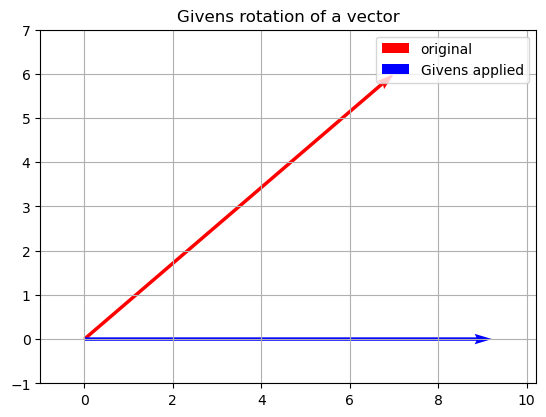

In [81]:
a, b = 7.0, 6.0
v = np.array([a,b])
c, s, r = givens_rotation(a, b)
G = np.array([[c,s],[-s,c]])
v_rotated = G @ v
plt.figure()
plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.007, label='original')
plt.quiver(0, 0, v_rotated[0], v_rotated[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.007, label='Givens applied')
plt.xlim(-1, max(v[0], v_rotated[0]) + 1)
plt.ylim(-1, max(v[1], v_rotated[1]) + 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.legend()
plt.title("Givens rotation of a vector")
plt.show()

## QR decomposition

In [82]:
def givens_cs(a,b):
    if b == 0:
        return 1.0, 0.0
    r = np.hypot(a,b)
    c = a / r
    s = - b / r
    return c, s

def givens_qr(A, tol = 1e-12):
    A = np.array(A, dtype=np.float64, copy=True)
    m,n = A.shape
    Q = np.eye(m)

    for i in range(min(n,m)): # i is the current column, or the pivot row. we want to make this the upper triangular. zero all entries below the diagonal A[i,i]
        # zero out the entries below diagonal in column i using given's rotations:
        for j in range(m-1, i, -1): # iterate over all the rows below row i, starting from the bottom m-1 and moving upwards i+1
            a = A[i,i]
            b = A[j,i]
            if abs(b) <= tol:
                continue
            c, s = givens_cs(a, b)
            G = np.eye(m)
            G[i,i] = c
            G[j,j] = c
            G[i,j] = -s
            G[j,i] = s
            A = G @ A
            Q = Q @ G.T

    R = A
    return Q, R


In [83]:
# Testing code :

A = np.array( [[1,-1,4],[1,4,-2],[1,4,2],[1,-1,0]])
Q, R = givens_qr(A)
print(np.round(Q,2))
print(np.round(R,2))
print(np.round(Q@Q.T))

[[ 0.5 -0.5  0.5 -0.5]
 [ 0.5  0.5 -0.5 -0.5]
 [ 0.5  0.5  0.5  0.5]
 [ 0.5 -0.5 -0.5  0.5]]
[[ 2.  3.  2.]
 [ 0.  5. -2.]
 [ 0. -0.  4.]
 [ 0. -0.  0.]]
[[ 1.  0.  0. -0.]
 [ 0.  1. -0.  0.]
 [ 0. -0.  1.  0.]
 [-0.  0.  0.  1.]]


In [84]:
np.allclose(Q @ R, A, atol=1e-12)  # this line would break if we don't use float64 as dtype.


True

## Showing non-uniqueness of QR

In [85]:
np.random.seed(37)
A = np.random.randint(1,10,size=(4,3))
#A = np.array(A, dtype=np.float64, copy=True)
print("A:\n" , np.round(A,2))

Qg, Rg = givens_qr(A)
print("QR decomposition using givens")
print("Qg:\n", np.round(Qg,2))
print("Rg:\n", np.round(Rg,2))
print("Qg x Rg:\n", np.round(Qg @ Rg,2))
print("Qg x Qg.T")
print(np.round(Qg @ Qg.T,2))


A:
 [[6 7 4]
 [4 6 9]
 [6 8 9]
 [9 4 3]]
QR decomposition using givens
Qg:
 [[ 0.46  0.3  -0.77  0.34]
 [ 0.31  0.43  0.61  0.59]
 [ 0.46  0.47  0.14 -0.74]
 [ 0.69 -0.71  0.15  0.01]]
Rg:
 [[13.   11.54 10.85]
 [ 0.    5.64  7.24]
 [-0.   -0.    4.12]
 [ 0.    0.   -0.  ]]
Qg x Rg:
 [[6. 7. 4.]
 [4. 6. 9.]
 [6. 8. 9.]
 [9. 4. 3.]]
Qg x Qg.T
[[ 1.  0. -0. -0.]
 [ 0.  1.  0. -0.]
 [-0.  0.  1. -0.]
 [-0. -0. -0.  1.]]


### comments and conclusion

- tolerance level should be dependant on the dtype used. the machine epsilon should be under consideration when deciding tolerance.
- the givens rotation goes bottoms up in a column, not top to bottom to avoid reintroducing non-zero elemsnts in already zeros entry.
- *QR decomposition is NOT unique*

In [86]:
np.allclose(A, Qg@Rg, atol=1e-12)
Qnum, Rnum = np.linalg.qr(A, mode='complete')
print("Qnum:\n", np.round(Qnum,2))
print(np.round(Qnum,2))
print(np.round(Rnum,2))

Qnum:
 [[-0.46 -0.3   0.77  0.34]
 [-0.31 -0.43 -0.61  0.59]
 [-0.46 -0.47 -0.14 -0.74]
 [-0.69  0.71 -0.15  0.01]]
[[-0.46 -0.3   0.77  0.34]
 [-0.31 -0.43 -0.61  0.59]
 [-0.46 -0.47 -0.14 -0.74]
 [-0.69  0.71 -0.15  0.01]]
[[-13.   -11.54 -10.85]
 [  0.    -5.64  -7.24]
 [  0.     0.    -4.12]
 [  0.     0.     0.  ]]


In [87]:
print("Qnum:\n", np.round(Qnum,2))
print("Qg:\n", np.round(Qg,2))

print("Rg:\n", np.round(Rg,2))
print(np.round(Rnum,2))
print(np.allclose(abs(Qg), abs(Qnum), atol=1e-12))
print(np.allclose(abs(Rg), abs(Rnum), atol=1e-12))
print(np.allclose(Qg, Qnum, atol=1e-12))
print(np.allclose(Rg, Rnum, atol=1e-12))

Qnum:
 [[-0.46 -0.3   0.77  0.34]
 [-0.31 -0.43 -0.61  0.59]
 [-0.46 -0.47 -0.14 -0.74]
 [-0.69  0.71 -0.15  0.01]]
Qg:
 [[ 0.46  0.3  -0.77  0.34]
 [ 0.31  0.43  0.61  0.59]
 [ 0.46  0.47  0.14 -0.74]
 [ 0.69 -0.71  0.15  0.01]]
Rg:
 [[13.   11.54 10.85]
 [ 0.    5.64  7.24]
 [-0.   -0.    4.12]
 [ 0.    0.   -0.  ]]
[[-13.   -11.54 -10.85]
 [  0.    -5.64  -7.24]
 [  0.     0.    -4.12]
 [  0.     0.     0.  ]]
True
True
False
False
